In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from biodata.delimited import DelimitedReader
import numpy as np
import pyBigWig
from collections import defaultdict
import seaborn as sns
import itertools
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import json
from matplotlib.font_manager import FontProperties
from statannotations.Annotator import Annotator
from scipy.stats import ks_2samp

In [3]:
import matplotlib
from pathlib import Path
font_dir = Path.cwd().parent / "font"
for font in ["Arial.ttf", "Arial_Bold.ttf"]:
    matplotlib.font_manager.fontManager.addfont(font_dir / font)
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9

In [1]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

# DE analysis

In [4]:
s = "HCT116"

## Metadata

In [5]:
df_metadata = pd.DataFrame({"Condition": ["U", "U", "T", "T"]}, columns=["Condition"], index=["U1", "U2", "T1", "T2"])
outputfile = f"{PROJECT_DIR_o}DE/{s}_metadata.txt"
df_metadata.to_csv(outputfile, sep="\t")

## Count data

In [6]:
s = "HCT116"
ks = ["pl", "mn"]
ts = ["minTSS", "maxTSS"]
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]
gs = [f"{p}_{d}" for p, d in itertools.product(ps, ds)]
labels = ["Up", "Unchanged", "Down"]

In [7]:
reps = list(df_metadata.index)
bws = {}
for r in reps:
	bws[r] = [f"{PROJECT_DIR_d}Alignments/CTCF_{r}_5{k}.bw" for k in ks]

In [8]:
results = []
index = []
for g in gs:
	inputfile = f"{PROJECT_DIR_d}bed_plot/{s}_{g}.bed"
	df = pd.read_table(inputfile, header=None)
	for _, row in df.iterrows():
		chrom, start, end = row[:3]
		sign = row[7]
		for t in ts:
			index.append("_".join([chrom, str(start), str(end), t, g]))
			row = []
			for r in bws:
				pl, mn = bws[r]
				bw1 = pyBigWig.open(pl)
				bw2 = pyBigWig.open(mn)
				reads1 = 0
				reads2 = 0
				
				if bw1.intervals(chrom, start, end) != None:
					for start2, end2, score in bw1.intervals(chrom, start, end):
						l = min(end, end2) - max(start, start2)
						reads1 += abs(score) * l
				if bw2.intervals(chrom, start, end) != None:
					for start2, end2, score in bw2.intervals(chrom, start, end):
						l = min(end, end2) - max(start, start2)
						reads2 += abs(score) * l
			
				if t == "maxTSS":
					row.append(reads1 if sign == "+" else reads2)
				else:
					row.append(reads2 if sign == "+" else reads1)
			results.append(row)
			
df_counts = pd.DataFrame(results, columns=reps, index=index).T
outputfile = f"{PROJECT_DIR_o}DE/{s}_counts.txt"
df_counts.to_csv(outputfile, sep="\t")

## Run DESeq2

In [ ]:
# DESeq2 analysis with only two replicates: https://support.bioconductor.org/p/106403/
# Michael Love: As long as there is one "degree of freedom", DESeq2 can estimate dispersion. 

In [ ]:
# https://www.bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html#indfilttheory
# Pre-filtering step can be omitted entirely and just rely on the independent filtering procedures

In [ ]:
# https://www.bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html#pvaluesNA
# https://www.bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html#indfilt
# Some values in the results table can be set to NA for one of the following reasons:
# 1. If within a row, all samples have zero counts, the baseMean column will be zero, and the log2 fold change estimates, p value and adjusted p value will all be set to NA.
# 2. If a row contains a sample with an extreme count outlier then the p value and adjusted p value will be set to NA. These outlier counts are detected by Cook’s distance. 
# 3. If a row is filtered by automatic independent filtering, for having a low mean normalized count, then only the adjusted p value will be set to NA. The results function of the DESeq2 package performs independent filtering by default using the mean of normalized counts as a filter statistic. A threshold on the filter statistic is found which optimizes the number of adjusted p values lower than a significance level alpha. The adjusted p values for the elements which do not pass the filter threshold are set to NA.

In [ ]:
# PyDESeq2 is a python implementation of the DESeq2 method

In [9]:
# Create DeseqDataSet object
dds = DeseqDataSet(
	counts=df_counts,
	metadata=df_metadata,
	design_factors="Condition",
	ref_level=["Condition","U"]
)
# Fit dispersions and LFCs
dds.deseq2()
# Compute p-values and adjusted p-values
stat_res = DeseqStats(dds)
stat_res.summary()
# Get results
res = stat_res.results_df
res = res.dropna()
res["log2baseMean"] = np.log2(res["baseMean"])
conditions = [
	(res['padj'] < 0.05) & (res['log2FoldChange'] > 1),
	(res['padj'] < 0.05) & (res['log2FoldChange'] < -1),
]
choices = ['Up', 'Down']
res['Label'] = np.select(conditions, choices, default='Unchanged')
outputfile = f"{PROJECT_DIR_o}DE/{s}_DE.txt"
res.to_csv(outputfile, sep="\t")

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 3.10 seconds.

Fitting dispersion trend curve...
... done in 5.97 seconds.

/home/yc2553/miniconda3_new/envs/cy2/lib/python3.9/site-packages/pydeseq2/dds.py:363: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 2.81 seconds.

Fitting LFCs...
... done in 2.74 seconds.

Refitting 0 outliers.

Running Wald tests...
... done in 2.57 seconds.



Log2 fold change & Wald test p-value: Condition T vs U


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
chr1_998781_999282_minTSS_divergent_distal,6.822060,0.410868,0.973365,0.422111,6.729442e-01,9.998667e-01
chr1_998781_999282_maxTSS_divergent_distal,84.714796,0.078077,0.347616,0.224606,8.222860e-01,9.998667e-01
chr1_1001579_1002080_minTSS_divergent_distal,54.694690,0.449871,0.400299,1.123838,2.610819e-01,9.721837e-01
chr1_1001579_1002080_maxTSS_divergent_distal,542.290290,-2.205273,0.276195,-7.984483,1.411124e-15,4.395716e-13
chr1_1006252_1006753_minTSS_divergent_distal,59.804443,0.154751,0.390121,0.396676,6.916066e-01,9.998667e-01
...,...,...,...,...,...,...
chrX_152637549_152638050_maxTSS_unidirectional_proximal,475.155546,0.588551,0.277797,2.118635,3.412134e-02,3.990893e-01
chrX_153470449_153470950_minTSS_unidirectional_proximal,66.515651,5.970649,0.739410,8.074885,6.754041e-16,2.293267e-13
chrX_153470449_153470950_maxTSS_unidirectional_proximal,379.218917,-0.265442,0.265358,-1.000317,3.171572e-01,9.998667e-01
chrX_153763899_153764400_minTSS_unidirectional_proximal,0.520815,0.556961,3.563324,0.156304,8.757936e-01,NaN


/home/yc2553/tmp/ipykernel_1976803/2073892516.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res["log2baseMean"] = np.log2(res["baseMean"])
/home/yc2553/tmp/ipykernel_1976803/2073892516.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res['Label'] = np.select(conditions, choices, default='Unchanged')


## Volcano plot

In [10]:
def volcano_plot(res, d, t, loc, outputfile):
	fig, ax = plt.subplots(figsize=(3.2,2.8))
	res2 = res[res.index.str.contains(d) & res.index.str.contains(t)].dropna()
	res2["-log10padj"] = -np.log10(res2["padj"])
	g = sns.scatterplot(data=res2, x="log2FoldChange", y="-log10padj", 
						hue="Label", hue_order=labels,
						palette=["#FFD700","#d9d9d9","#b3de69"], 
						alpha=0.7, s=30, ax=ax)
	g.spines[["right", "top"]].set_visible(False)
	g.set_title(t, fontsize=bfontsize, fontweight="bold", pad=5)
	
	g.set_yticks([0,10,20,30,40])
	g.set_ylim([-2,48])
	g.set_ylabel(r"-log$_{10}$(q-value)", fontsize=bfontsize, fontweight="bold")

	g.set_xlim([-10.5, 10.5])
	g.set_xlabel(r"log$_2$(6h/0h)", fontsize=bfontsize, fontweight="bold")
	
	g.tick_params(labelsize=sfontsize)
	
	legend = g.legend(loc=loc, frameon=False, handletextpad=0, labelspacing=0.3)
	for label in labels:
		legend.get_texts()[labels.index(label)].set_text(label+" (n=" + str(len(res2[res2["Label"]==label])) + ")")
		legend.get_texts()[labels.index(label)].set_fontsize(sfontsize)
		
	plt.savefig(outputfile, bbox_inches="tight", dpi=300) 

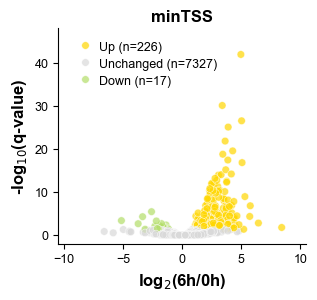

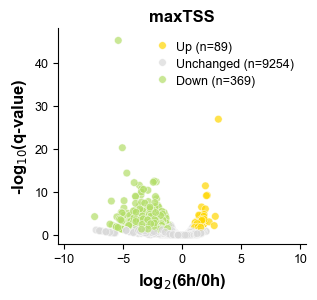

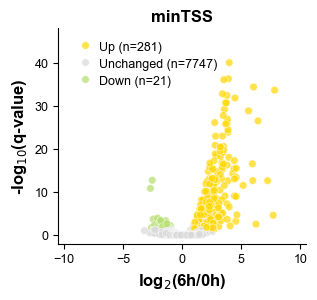

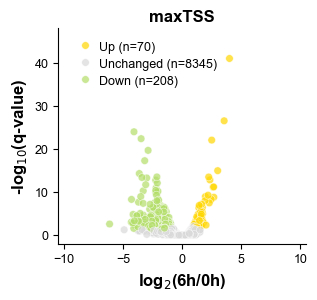

In [11]:
for d, t in itertools.product(ds, ts):
	loc = "upper right" if t == "maxTSS" and d == "distal" else "upper left"
	if d == "distal":
		outputfile = f"{PROJECT_DIR_o}figures/Fig4c.png" if t == "minTSS" else f"{PROJECT_DIR_o}figures/Fig4e.png"
	else:
		outputfile = f"{PROJECT_DIR_o}supp_figures/SuppFig10a.png" if t == "minTSS" else f"{PROJECT_DIR_o}supp_figures/SuppFig10c.png"
	volcano_plot(res, d, t, loc, outputfile)

In [12]:
# Get labels for each element

DE_labels = defaultdict(dict)
for t, g in itertools.product(ts, gs):
	inputfile = f"{PROJECT_DIR_d}bed_plot/{s}_{g}.bed"
	with DelimitedReader(inputfile) as dr:
		for cols in dr:
			chrom, start, end = cols[:3]
			e = "_".join([chrom, start, end, t, g])
			if e in res.index:
				DE_labels[t]["_".join([chrom, start, end])] = res.loc[e]["Label"]

In [13]:
outputfile = f"{PROJECT_DIR_o}labels/{s}_CTCF_DE.json"
with open(outputfile, "w") as f:
	json.dump(DE_labels, f)

# minTSS vs. maxTSS

## Categorical comparison

In [14]:
effects = defaultdict(dict)
for d, t in itertools.product(ds, ts):
	res2 = res[res.index.str.contains(d) & res.index.str.contains(t)].dropna()
	for label in labels:
		effects[(d,t)][label] = set(["_".join(e.split("_")[:3]) for e in res2[res2["Label"]==label].index])

In [15]:
# elements with both minimum/maximum side available

shared = {}
for d in ds:
	shared[d] = set().union(*effects[(d, "minTSS")].values()) & set().union(*effects[(d, "maxTSS")].values())

In [16]:
def plot_prop(d, group, lbs, effects, outputfile):
	row_group, col_group = group
	fig, ax = plt.subplots(figsize=(2.5,1))
	ax.axis('off')
	ax.axis('tight')
	
	results = []
	for label in lbs:
		row = []
		ns = [len(effects[(d, row_group)][label] & effects[(d, col_group)][label2] & shared[d]) for label2 in labels]
		ratios = []
		for n in range(3):
			if n != 2:
				ratios.append(round(ns[n]/sum(ns)*100,1))
				row.append(f"{ns[n]} ({ratios[n]}%)")
			else:
				row.append(f"{ns[n]} ({round(100-sum(ratios),1)}%)")
		results.append(row)
		
	colors = {"minTSS": "#a6cee3", "maxTSS": "#fb9a99"}
	rowColours=[colors[row_group]]*3
	colColours=[colors[col_group]]*3
	table = ax.table(cellText=results,
			  rowLabels=lbs,
			  rowColours=rowColours,
			  rowLoc="center",
			  colLabels=labels,
			  colColours=colColours,
			  colLoc="center",
			  cellLoc="center",
			  loc="center",
			  )
	table.scale(1.3, 3.5)
	
	table.auto_set_font_size(False)
	for (row, col), cell in table.get_celld().items():
		if (row == 0) or (col == -1):
			cell.set_text_props(fontproperties=FontProperties(weight='bold', size=sfontsize))
		else:
			cell.set_text_props(fontproperties=FontProperties(size=sfontsize))

	colors2 = {"minTSS": "#08519c", "maxTSS": "#a50f15"}
	ax.text(x=0, y=0.145, s=col_group, fontsize=bfontsize, ha="center", fontweight="bold", color=colors2[col_group])
	ax.text(x=-0.135, y=-0.04, s=row_group, fontsize=bfontsize, va="center", fontweight="bold", rotation=90, color=colors2[row_group])

	plt.savefig(outputfile, bbox_inches="tight", dpi=300) 

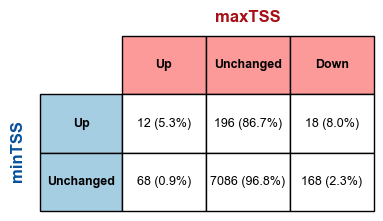

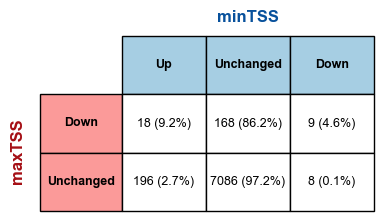

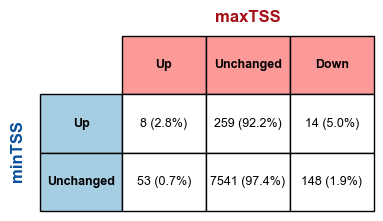

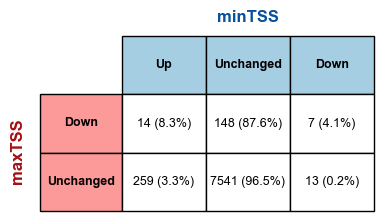

In [17]:
groups = [["minTSS", "maxTSS"], ["maxTSS", "minTSS"]]
lbs = [["Up", "Unchanged"], ["Down", "Unchanged"]]
for d in ds:
	folder = "supp_figures/" if d == "distal" else "other_figures/"
	for group, lb in zip(groups, lbs):
		if groups.index(group) == 0:
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig8a.pdf"
		else:
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig8b.pdf"
		plot_prop(d, group, lb, effects, outputfile)

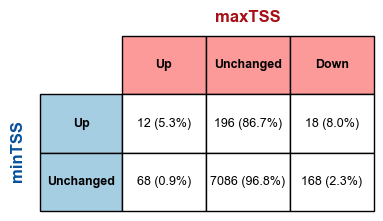

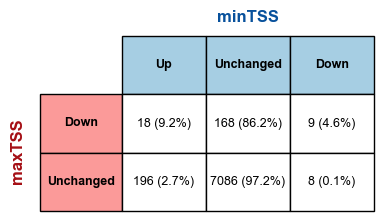

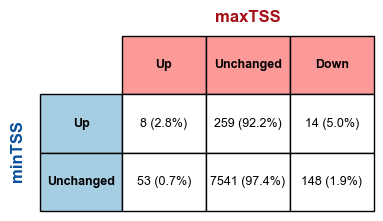

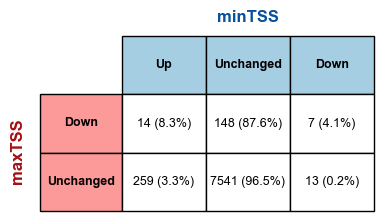

In [18]:
groups = [["minTSS", "maxTSS"], ["maxTSS", "minTSS"]]
lbs = [["Up", "Unchanged"], ["Down", "Unchanged"]]
for d in ds:
	folder = "supp_figures/" if d == "distal" else "other_figures/"
	for group, lb in zip(groups, lbs):
		if groups.index(group) == 0:
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig8a.pdf"
		else:
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig8b.pdf"
		plot_prop(d, group, lb, effects, outputfile)

## log2FC

In [19]:
# Get log2FC for each elements

fcs = defaultdict(dict)
for index, row in res.iterrows():
	chrom, start, end, t, p, d = index.split("_")
	e = "_".join([chrom, start, end])
	if e in shared[d]:
		fcs[d][(e,t)] = [row["log2FoldChange"], row["Label"]]

In [20]:
results = []
for d in ds:
	for e in shared[d]:
		results.append([d, e] + [v for t in ts for v in fcs[d][(e, t)]])		
columns = ["group", "element"] 
for t in ts:
	columns.extend([f"{t}_FC", t])
df_fc = pd.DataFrame(results, columns=columns)
df_fc.head(2)

,group,element,minTSS_FC,minTSS,maxTSS_FC,maxTSS
0,distal,chr6_6583795_6584296,-0.042815,Unchanged,-0.516101,Unchanged
1,distal,chr14_93960036_93960537,-0.412749,Unchanged,-0.317591,Unchanged


In [21]:
def plot_log2FC(d, t, df, outputfile):
	fig, ax = plt.subplots(figsize=(4,4))
	if t == "minTSS":
		lbs = ["Up", "Unchanged"]
		palette = ["#FFD700","#d9d9d9"]
	else:
		lbs = ["Down", "Unchanged"]
		palette = ["#b3de69","#d9d9d9"]
	df = df[(df[t].isin(lbs)) & (df["group"]==d)]
	g = sns.scatterplot(data=df, x="minTSS_FC", y="maxTSS_FC", hue=t, 
						hue_order=lbs, palette=palette, s=30, alpha=0.7, ax=ax)
	g.spines[["right", "top"]].set_visible(False)
	g.legend_.set_title(t, prop={"weight": "bold", "size":sfontsize})
	for text in g.legend_.get_texts():
		text.set_fontsize(sfontsize)

	g.set_ylim([-10.5,10.5])
	g.set_yticks([-10,-5,0,5,10])
	g.set_ylabel("log$_2$FC (maxTSS)", fontsize=bfontsize, fontweight="bold")
		
	g.set_xlim([-10.5,10.5])
	g.set_xticks([-10,-5,0,5,10])
	g.set_xlabel("log$_2$FC (minTSS)", fontsize=bfontsize, fontweight="bold")

	g.tick_params(labelsize=sfontsize)

	plt.savefig(outputfile, bbox_inches = 'tight', dpi=300) 

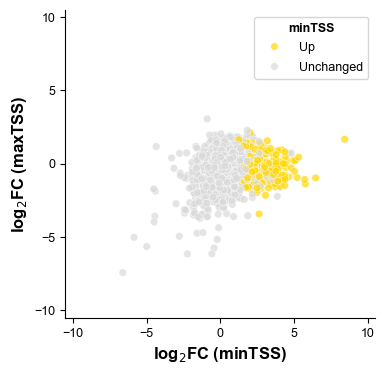

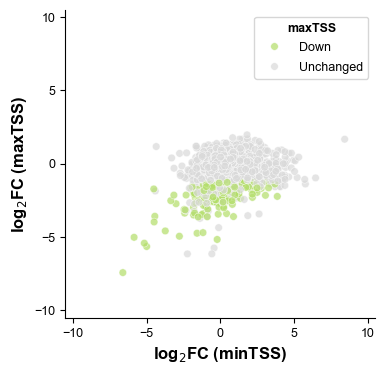

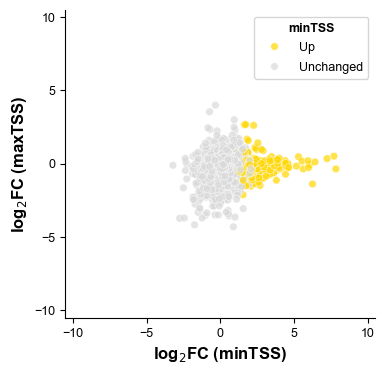

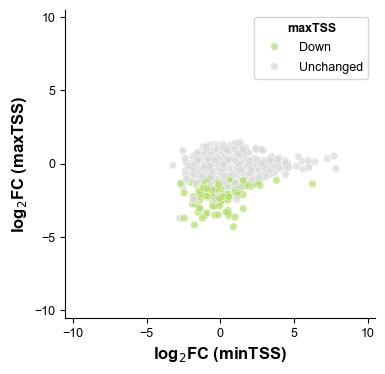

In [22]:
for d in ds:
	folder = "supp_figures/" if d == "distal" else "other_figures/"
	for t in ts:
		if t == "minTSS":
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig8c.png"
		else:
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig8d.png"
		plot_log2FC(d, t, df_fc, outputfile)

## Directionality index changes

In [23]:
bws2 = {"0h": [f"{PROJECT_DIR_d}Alignments/brm_CTCF_U1_and_CTCF_U2_erm_5{k}.bw" for k in ks],
	   "6h": [f"{PROJECT_DIR_d}Alignments/brm_CTCF_T1_and_CTCF_T2_erm_5{k}.bw" for k in ks]
	  }

In [24]:
def get_DI(bws, es):
	pl, mn = bws
	bw1 = pyBigWig.open(pl)
	bw2 = pyBigWig.open(mn)
	
	DIs = {}
	for e in es:
		reads1 = 0
		reads2 = 0
		chrom, start, end = e.split("_")
		start = int(start)
		end = int(end)
		if bw1.intervals(chrom, start, end) != None:
			for start2, end2, score in bw1.intervals(chrom, start, end):
				l = min(end, end2) - max(start, start2)
				reads1 += abs(score) * l
		if bw2.intervals(chrom, start, end+1) != None:
			for start2, end2, score in bw2.intervals(chrom, start, end):
				l = min(end, end2) - max(start, start2)
				reads2 += abs(score) * l
		if reads1+reads2 > 0:
			DIs[e] = (reads1-reads2)/(reads1+reads2)
	return DIs

In [25]:
DIs = {}
for d in ds:
	for k in bws2:
		DIs[(d,k)] = get_DI(bws2[k], shared[d])

In [26]:
results = []
for d in ds:
	for e in shared[d]:
		results.extend([[d, e, DIs[(d,k)][e], k] for k in bws2])
df_DI = pd.DataFrame(results, columns=["group", "element", "DI", "time"])
df_DI.head(2)

,group,element,DI,time
0,distal,chr6_6583795_6584296,-0.047619,0h
1,distal,chr6_6583795_6584296,-0.200000,6h


In [27]:
df_merged = df_DI.merge(df_fc, on=["group", "element"])
df_merged.head(2)

,group,element,DI,time,minTSS_FC,minTSS,maxTSS_FC,maxTSS
0,distal,chr6_6583795_6584296,-0.047619,0h,-0.042815,Unchanged,-0.516101,Unchanged
1,distal,chr6_6583795_6584296,-0.200000,6h,-0.042815,Unchanged,-0.516101,Unchanged


In [28]:
def plot_DI_changes(d, t, df_merged, outputfile):
	fig, ax = plt.subplots(figsize=(4,3.5))
	if t == "minTSS":
		l = "Up"
		color = ["#FFD700"]*2
	else:
		l = "Down"
		color = ["#b3de69"]*2

	df = df_merged[(df_merged["group"]==d) & (df_merged[t]==l)]
	hue_plot_params = {
				"data": df,
				"x": "time",
				"y": "DI",
				"palette": color,
				"cut": 0
			}
	g = sns.violinplot(ax=ax, **hue_plot_params)
	for violin, alpha in zip(g.collections[::2], [0.5,1]):
	    violin.set_alpha(alpha)
	g.spines[["right", "top"]].set_visible(False)
	
	g.set_ylabel("Directionality index", fontsize=bfontsize, fontweight="bold")
	g.set_yticks([-1,-0.5,0,0.5,1])
	g.tick_params(axis="y", labelsize=sfontsize)

	g.set_xlabel("")
	g.tick_params(axis="x", labelsize=bfontsize)
	for label in g.get_xticklabels():
	    label.set_fontweight('bold')

	group1 = list(df[df["time"]=="0h"]["DI"])
	group2 = list(df[df["time"]=="6h"]["DI"])
	pvalue = ks_2samp(group1, group2)[1]
	annotator = Annotator(g, [["0h", "6h"]], **hue_plot_params)
	annotator.configure(text_format="star", verbose=False, text_offset=1, loc="outside")
	annotator.set_pvalues([pvalue]).annotate()	

	plt.savefig(outputfile, bbox_inches = 'tight', dpi=300) 

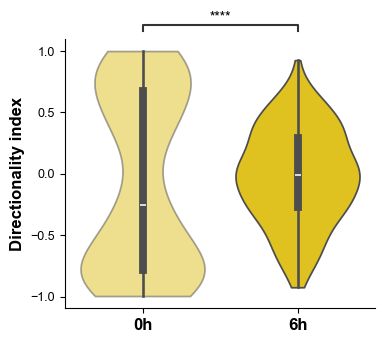

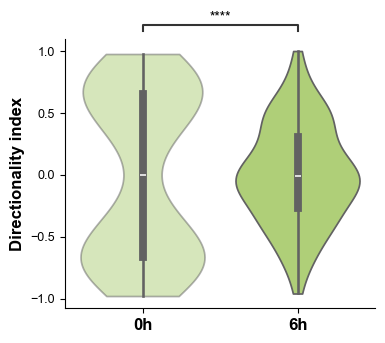

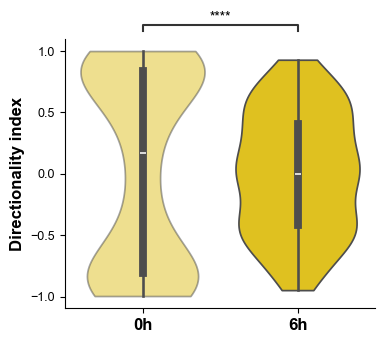

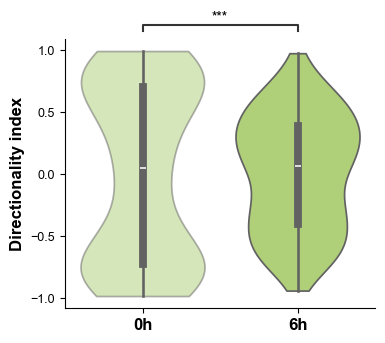

In [29]:
for d, t in itertools.product(ds, ts):
	n = 8 if d == "distal" else 10
	if t == "minTSS":
		outputfile = f"{PROJECT_DIR_o}supp_figures/SuppFig{n}e.pdf"
	else:
		outputfile = f"{PROJECT_DIR_o}supp_figures/SuppFig{n}f.pdf"
	plot_DI_changes(d, t, df_merged, outputfile)